In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


#1


In [2]:
X_fantoma = np.array([
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

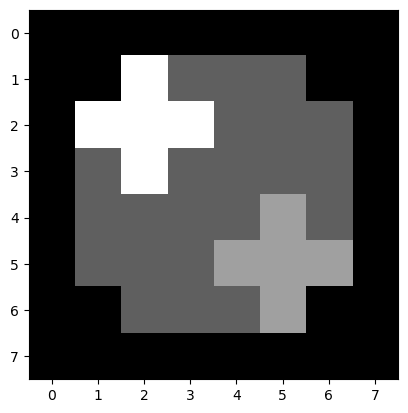

In [3]:
#A
x= plt.imshow(X_fantoma, cmap="gray")

In [4]:
#B
x_fantoma= X_fantoma.reshape(-1)
x_fantoma

array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.8, 0.3, 0.3,
       0.3, 0. , 0. , 0. , 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0. , 0. , 0.3,
       0.8, 0.3, 0.3, 0.3, 0.3, 0. , 0. , 0.3, 0.3, 0.3, 0.3, 0.5, 0.3,
       0. , 0. , 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0. , 0. , 0. , 0.3, 0.3,
       0.3, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ])

In [5]:
#C
X_temp=[]
i=0
j=0
z=0
while(i<8):
    temp = []
    while(j<8):
        temp.append(x_fantoma[z])
        j+=1
        z+=1
    j=0
    X_temp.append(temp)
    i+=1


X_fantoma_recon = np.array(X_temp,dtype=float)
X_fantoma_recon

array([[0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.8, 0.3, 0.3, 0.3, 0. , 0. ],
       [0. , 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0. ],
       [0. , 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0. ],
       [0. , 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0. ],
       [0. , 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0. ],
       [0. , 0. , 0.3, 0.3, 0.3, 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ]])

D
el valor de una compente x_k es el coeficiente de atenuidad recibida por los receptores a la hora de emitir los rayos x al realizar la tomografía, se considera una atenuidad alta (se recibe poca informacion de rayos x) a valores cercanos a 1, mientras que por el contrario se considera una atenuidad baja a los valores cercanos a 0 (se recibe en gran cantidad la informacion eviada por los rayos x), en esta imagen podemos notar como en los pixeles centrales se recibe menos información.
**escrito asi nomas, despues hay q reescribir**

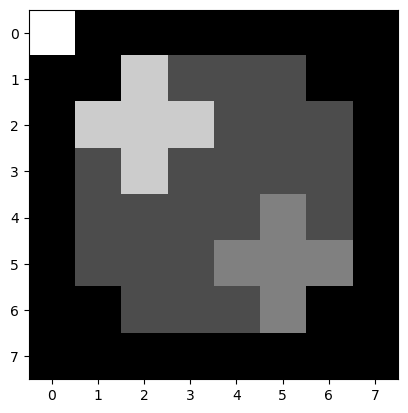

In [6]:
X_fantoma_mod = np.array([
[1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

x= plt.imshow(X_fantoma_mod, cmap="gray")


en el vector x_fantona cambia el pixel x_0
i x 8 : cuantas filas me tengo que mover desde la fila 0 para llegar a la fila donde a la que pertenece el pixel (i,j) 
j : parandome en el primer elemento de la fila a la que pertenece el pixel, a que columna me debo mover.


#2

In [7]:
#a
def mascara_rayo(n, direccion, s):
    M = np.zeros((n, n), dtype=int)
    i=0
    while(i<len(M)):
        j=0
        while j < len(M[i]):
            if direccion[0]*i + direccion[1]*j == s:
                M[i][j] = 1
            j+=1
        i+=1

    return M


In [8]:
#b
A= mascara_rayo(8,(1,0),3)
B= mascara_rayo(8,(0,1),5)
C= mascara_rayo(8,(1,1),7)
D= mascara_rayo(8,(1,-1),0)
E= mascara_rayo(8,(2,1),8)

In [9]:
A

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

In [10]:
B

array([[0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0]])

In [11]:
C

array([[0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0]])

In [12]:
D

array([[1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 1]])

In [13]:
E

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

In [14]:
def medicion_br(X_Fantoma, M_r):
    i=0
    br=0
    while(i < len(X_Fantoma)): #sabiendo que la matriz fantoma es de 8x8 al igual que M_r
        j=0
        while(j < len(X_Fantoma[0])):
            br += M_r[i][j] * X_Fantoma[i][j]
            j+=1
        j=0
        i+=1
    return br
result = medicion_br(X_fantoma, A)
result


np.float64(2.3)

#3